# Phase 6: Insights & Reporting

Phases 0-5 (data audit/rebuild, feature engineering, deep EDA, statistical validation, derived
metrics, modeling) are all done. This notebook is **synthesis, not new analysis** (`plan.md`
§7): it consolidates the 13 `Output/*.csv` files already produced into (a) one restaurant
-level master table, (b) one business action list, (c) 5 cross-phase summary charts, and
states business takeaways + a limitations section grounded in what's already on record. Its
narrative content is reassembled into a companion `Report.md` afterward, for a reader who
won't open this notebook.

**All prices in plain INR, no conversion factor** (India-only scope, `plan.md` §0.3).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chart styling: the project's editorial palette, reused verbatim from Modeling.ipynb.
ACCENT = '#2a78d6'
WARN = '#c1502e'
INK = '#0b0b0b'
INK_2 = '#52514e'
MUTED = '#898781'
GRID = '#e1e0d9'
AXIS = '#c3c2b7'
SURFACE = '#fcfcfb'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK_2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 1, 'grid.linestyle': '-',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'semibold', 'axes.titlecolor': INK,
})
os.makedirs('Output/charts', exist_ok=True)

In [2]:
# Output/ CSVs are written by pandas as UTF-8 (only the raw zomato.csv needs latin-1)
df = pd.read_csv('Output/df_featured.csv')
RATING = 'Aggregate rating'
ALPHA = 0.05

cred_df = pd.read_csv('Output/credibility_weighted_ratings.csv')
vfm_df = pd.read_csv('Output/value_for_money_residuals.csv')
density_df = pd.read_csv('Output/competition_density.csv')
rating_pred_df = pd.read_csv('Output/rating_model_predictions.csv')
coldstart_df = pd.read_csv('Output/coldstart_risk_scores.csv')
cuisine_pair_df = pd.read_csv('Output/cuisine_pair_premium.csv')
opportunity_df = pd.read_csv('Output/locality_opportunity_flags.csv')

print(f"df: {df.shape}")
for name, d in [('credibility_weighted_ratings', cred_df), ('value_for_money_residuals', vfm_df),
                ('competition_density', density_df), ('rating_model_predictions', rating_pred_df),
                ('coldstart_risk_scores', coldstart_df), ('cuisine_pair_premium', cuisine_pair_df),
                ('locality_opportunity_flags', opportunity_df)]:
    print(f"  {name}: {d.shape}")

df: (8643, 24)
  credibility_weighted_ratings: (6504, 9)
  value_for_money_residuals: (6504, 12)
  competition_density: (7550, 9)
  rating_model_predictions: (6504, 4)
  coldstart_risk_scores: (8643, 6)
  cuisine_pair_premium: (83, 9)
  locality_opportunity_flags: (167, 10)


### Observation:
`df` loads at the expected 8,643 x 24 shape, and all 7 Phase 3.5/5 output files load at exactly
the row counts each phase's own notebook reported when it saved them — confirms nothing has
drifted since those notebooks last ran, so this synthesis is building on a consistent base.

## 1. Consolidated restaurant-level master table

Left-joins every restaurant-level Phase 3.5/5 output onto `df_featured.csv` by `Restaurant ID`.
**Deliberately not merged in** (model/test-level or composite-keyed, not restaurant-level):
`phase4_test_results.csv`, `rating_model_comparison.csv`, `rating_feature_importance.csv`,
`coldstart_feature_importance.csv`, `cuisine_pair_premium.csv`, and the two locality crosstabs /
`locality_opportunity_flags.csv` (those feed §2 or the charts directly instead). Phase 3.5's
cost-only `Residual` is renamed `VFM_*` on the way in so it never collides with Phase 5's
full-feature `Model_Residual` -- the two are kept as deliberately separate lenses (see chart 3).

In [3]:
master = df.copy()

master = master.merge(
    cred_df[['Restaurant ID', 'Cred_Rating', 'shrinkage_weight', 'rank_raw', 'rank_cred', 'rank_change']],
    on='Restaurant ID', how='left')

vfm_renamed = vfm_df[['Restaurant ID', 'Log_Cost', 'Predicted_Rating', 'Residual', 'rank_overall', 'rank_within_ncr_group']].rename(
    columns={'Predicted_Rating': 'VFM_Predicted_Rating', 'Residual': 'VFM_Residual',
             'rank_overall': 'VFM_rank_overall', 'rank_within_ncr_group': 'VFM_rank_within_ncr'})
master = master.merge(vfm_renamed, on='Restaurant ID', how='left')

master = master.merge(
    density_df[['Restaurant ID', 'Competitors_500m', 'Competitors_1km', 'Competitors_2km', 'density_tier']],
    on='Restaurant ID', how='left')
master['Has_Density_Data'] = master['Competitors_1km'].notna()

master = master.merge(rating_pred_df[['Restaurant ID', 'Model_Predicted_Rating', 'Model_Residual']],
                       on='Restaurant ID', how='left')
master = master.merge(coldstart_df[['Restaurant ID', 'Coldstart_Risk_Score']], on='Restaurant ID', how='left')

df_rated = df[df['Is Rated']].copy()

print(f"master: {master.shape}")
print(f"Cred_Rating non-null:        {master['Cred_Rating'].notna().sum():,} (expect 6,504)")
print(f"VFM_Residual non-null:       {master['VFM_Residual'].notna().sum():,} (expect 6,504)")
print(f"Has_Density_Data True:       {master['Has_Density_Data'].sum():,} (expect 7,550)")
print(f"Model_Residual non-null:     {master['Model_Residual'].notna().sum():,} (expect 6,504)")
print(f"Coldstart_Risk_Score non-null: {master['Coldstart_Risk_Score'].notna().sum():,} (expect 8,643)")

master: (8643, 42)
Cred_Rating non-null:        6,504 (expect 6,504)
VFM_Residual non-null:       6,504 (expect 6,504)
Has_Density_Data True:       7,550 (expect 7,550)
Model_Residual non-null:     6,504 (expect 6,504)
Coldstart_Risk_Score non-null: 8,643 (expect 8,643)


### Observation:
The master table lands at 8,643 x 42 (18 new columns beyond `df_featured.csv`'s 24). Every
non-null count matches its expected value exactly: 6,504 for the three rating-dependent merges
(`Cred_Rating`, `VFM_Residual`, `Model_Residual` — all undefined for unrated restaurants),
7,550 for `Has_Density_Data` (NCR restaurants with valid GPS), and the full 8,643 for
`Coldstart_Risk_Score` (the one Phase 5 output that covers every restaurant, rated or not).
No merge silently dropped or duplicated rows.

In [4]:
master.to_csv('Output/restaurant_master_insights.csv', index=False)
print("Saved Output/restaurant_master_insights.csv:", master.shape)

Saved Output/restaurant_master_insights.csv: (8643, 42)


### Observation:
Saved the full 8,643 x 42 consolidated table — every restaurant, every Phase 3.5/5 derived
column in one place, ready for Phase 6's own charts below or for any future ad hoc query
without re-joining 5 separate files.

## 2. Business action list

A single, uniformly-shaped action table stacked from 3 sources: every flagged locality
demand-supply gap (Phase 3.5), every cuisine pairing with a positive rating premium (Phase 3.5),
and a new cross-reference -- restaurants in the top decile of cold-start risk that also sit in
a flagged opportunity locality (the concrete version of the thread `Modeling.ipynb`'s own
summary flagged for this phase).

In [5]:
action_1 = opportunity_df.copy()
action_1['Action_Type'] = 'Locality demand-supply gap'
action_1['Location_or_Segment'] = action_1['Locality']
action_1['Metric_1_Name'] = 'AvgVotesPerRestaurant'
action_1['Metric_1_Value'] = action_1['AvgVotesPerRestaurant']
action_1['Metric_2_Name'] = 'Supply'
action_1['Metric_2_Value'] = action_1['Supply']
action_1['Source_File'] = 'locality_opportunity_flags.csv'
action_1 = action_1.rename(columns={'Is NCR': 'Is_NCR'})[
    ['Action_Type', 'Location_or_Segment', 'Metric_1_Name', 'Metric_1_Value',
     'Metric_2_Name', 'Metric_2_Value', 'Source_File', 'Is_NCR']]

action_2 = cuisine_pair_df[cuisine_pair_df['rating_premium'] > 0].copy()
action_2['Action_Type'] = 'Cuisine pairing premium'
action_2['Location_or_Segment'] = action_2['cuisine_a'] + ' + ' + action_2['cuisine_b']
action_2['Metric_1_Name'] = 'rating_premium'
action_2['Metric_1_Value'] = action_2['rating_premium']
action_2['Metric_2_Name'] = 'n_restaurants'
action_2['Metric_2_Value'] = action_2['n_restaurants']
action_2['Source_File'] = 'cuisine_pair_premium.csv'
action_2['Is_NCR'] = np.nan
action_2 = action_2[['Action_Type', 'Location_or_Segment', 'Metric_1_Name', 'Metric_1_Value',
                      'Metric_2_Name', 'Metric_2_Value', 'Source_File', 'Is_NCR']]

risk_threshold = master['Coldstart_Risk_Score'].quantile(0.9)
opportunity_localities = set(opportunity_df['Locality'])
high_risk_in_opportunity = master[
    (master['Coldstart_Risk_Score'] >= risk_threshold) & (master['Locality'].isin(opportunity_localities))
].copy()
action_3 = pd.DataFrame({
    'Action_Type': 'High-risk restaurant in opportunity locality',
    'Location_or_Segment': high_risk_in_opportunity['Restaurant Name'] + ' (' + high_risk_in_opportunity['Locality'] + ')',
    'Metric_1_Name': 'Coldstart_Risk_Score',
    'Metric_1_Value': high_risk_in_opportunity['Coldstart_Risk_Score'],
    'Metric_2_Name': 'Is Rated',
    'Metric_2_Value': high_risk_in_opportunity['Is Rated'].astype(int),
    'Source_File': 'restaurant_master_insights.csv + locality_opportunity_flags.csv',
    'Is_NCR': high_risk_in_opportunity['Is NCR'].values,
})

business_action_list = pd.concat([action_1, action_2, action_3], ignore_index=True)
print(business_action_list['Action_Type'].value_counts().to_string())

location_rows = business_action_list.dropna(subset=['Is_NCR'])
print(f"\nNCR share among location-based flagged rows: {location_rows['Is_NCR'].astype(bool).mean():.1%}")
print(f"Cold-start risk threshold (90th percentile): {risk_threshold:.3f}")

Action_Type
High-risk restaurant in opportunity locality    430
Locality demand-supply gap                      167
Cuisine pairing premium                          56

NCR share among location-based flagged rows: 99.7%
Cold-start risk threshold (90th percentile): 0.890


### Observation:
653 candidate actions split 430 / 167 / 56 across the three sources. The 430 "high-risk
restaurant in opportunity locality" rows (restaurants at or above the 90th-percentile
cold-start risk score of 0.890, sitting in one of the 167 flagged localities) is a genuinely
new number — it didn't exist as a single figure in any prior notebook, since it requires
exactly the restaurant-level x locality-level cross-reference this phase was built for.
The 99.7% NCR share here is computed across the *combined* 597 location-based rows
(167 locality flags + 430 restaurant flags), not the same denominator as the original
98.8%/165-of-167 figure from `Derived_Metrics.ipynb` (locality flags alone) — both point the
same direction, they just aren't the same count.

In [6]:
business_action_list.to_csv('Output/business_action_list.csv', index=False)
print("Saved Output/business_action_list.csv:", business_action_list.shape)

Saved Output/business_action_list.csv: (653, 8)


### Observation:
Saved all 653 action rows in one uniformly-shaped table — a single file a downstream team could
filter/sort by `Action_Type` without needing to know which of the 3 source files each row
originally came from.

## 3. Summary charts

Five curated, cross-phase syntheses -- each recombines data across at least two prior phases,
rather than re-plotting anything already shown. Saved to `Output/charts/` for `Report.md`.

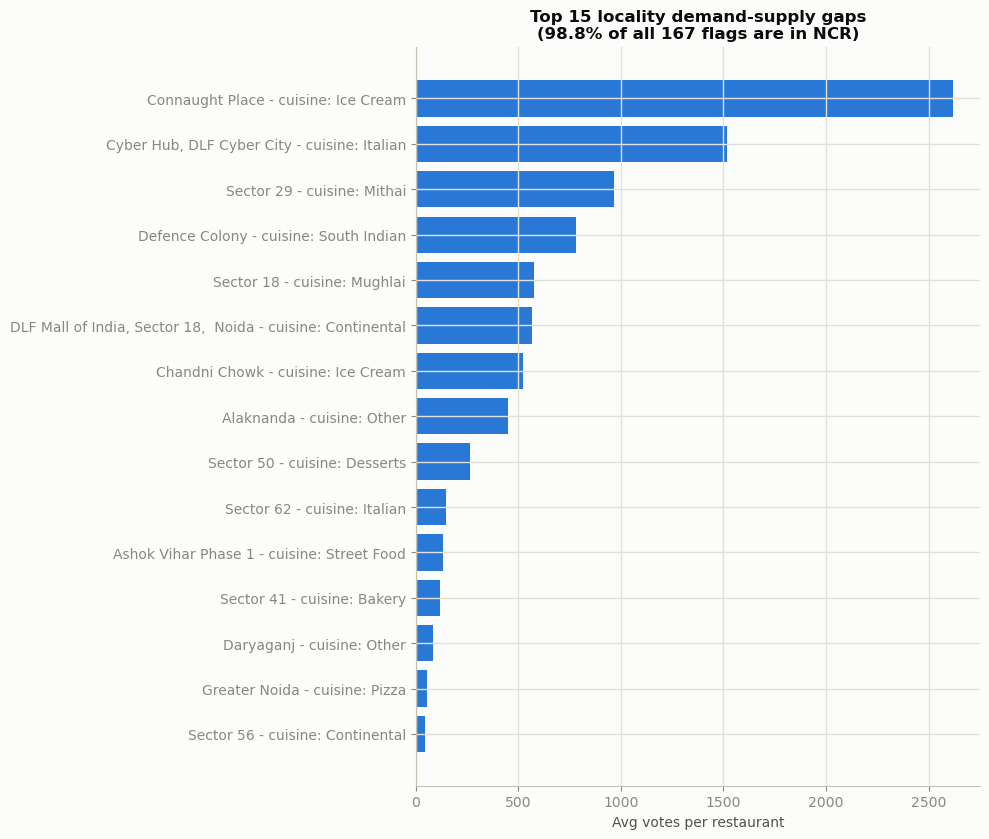

In [7]:
top15_opp = opportunity_df.sort_values('percentile_rank', ascending=False).head(15).copy()
top15_opp['label'] = top15_opp['Locality'] + ' - ' + top15_opp['category_type'] + ': ' + top15_opp['category_value'].astype(str)
top15_opp = top15_opp.sort_values('AvgVotesPerRestaurant')
ncr_share_flags = opportunity_df['Is NCR'].mean()

plt.figure(figsize=(10, 8.5))
plt.barh(top15_opp['label'], top15_opp['AvgVotesPerRestaurant'], color=ACCENT)
plt.xlabel('Avg votes per restaurant')
plt.title(f'Top 15 locality demand-supply gaps\n({ncr_share_flags:.1%} of all {len(opportunity_df)} flags are in NCR)',
          fontsize=12)
plt.tight_layout()
plt.savefig('Output/charts/01_growth_opportunities.png', dpi=150)
plt.show()

### Observation:
The top 15 flagged gaps are dominated by "Other"/niche cuisine buckets and Ice Cream/Continental
categories in high-traffic NCR localities — consistent with `Derived_Metrics.ipynb`'s own finding
that Ice Cream showed up as a thin-supply, high-demand niche in two separate top localities
(Chandni Chowk, Connaught Place). The chart title's NCR share (98.8%) restates the scope
limitation directly on the chart itself, not just in prose.

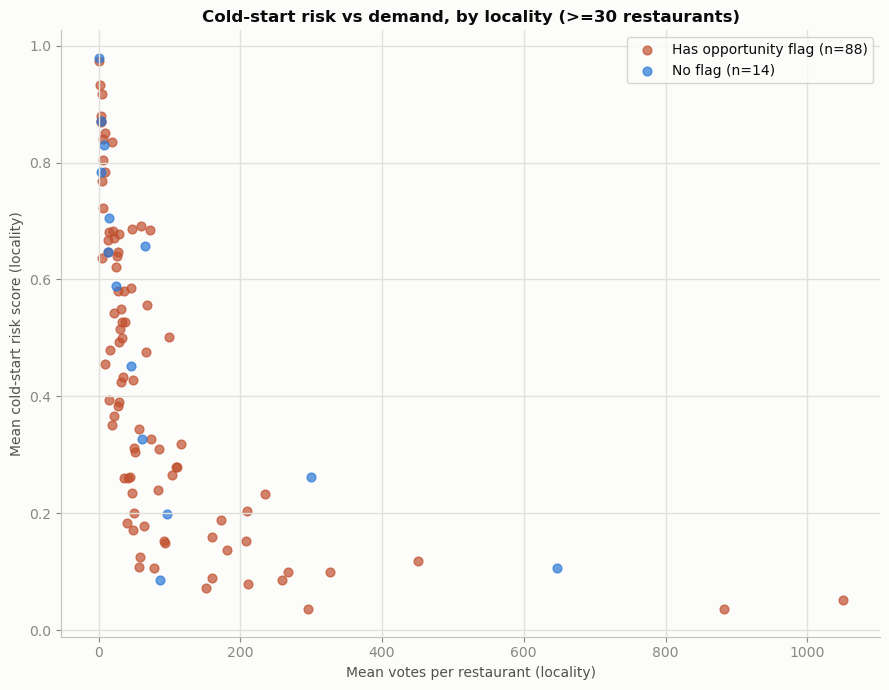

In [8]:
locality_agg = master.groupby('Locality').agg(
    Mean_Coldstart_Risk=('Coldstart_Risk_Score', 'mean'),
    Mean_Votes=('Votes', 'mean'),
    Supply=('Restaurant ID', 'count'),
).reset_index()
locality_agg = locality_agg[locality_agg['Supply'] >= 30].copy()
locality_agg['Has_Opportunity_Flag'] = locality_agg['Locality'].isin(opportunity_localities)

plt.figure(figsize=(9, 7))
for flag, color, label in [(True, WARN, 'Has opportunity flag'), (False, ACCENT, 'No flag')]:
    sub = locality_agg[locality_agg['Has_Opportunity_Flag'] == flag]
    plt.scatter(sub['Mean_Votes'], sub['Mean_Coldstart_Risk'], s=40, alpha=0.7, color=color, label=f'{label} (n={len(sub)})')
plt.xlabel('Mean votes per restaurant (locality)')
plt.ylabel('Mean cold-start risk score (locality)')
plt.title('Cold-start risk vs demand, by locality (>=30 restaurants)')
plt.legend()
plt.tight_layout()
plt.savefig('Output/charts/02_coldstart_vs_opportunity.png', dpi=150)
plt.show()

### Observation:
88 of the 102 qualifying localities (≥30 restaurants) carry at least one opportunity flag, 14
don't — consistent with the 98.8% NCR concentration already established. The dominant pattern is
that **mean cold-start risk falls sharply as locality-level demand rises**, and that curve looks
essentially the same whether or not a locality is flagged (orange and blue points are
interleaved at every risk level, not separated into two bands) — flag status and cold-start risk
turn out to be largely independent signals here, not two views of the same thing. That's exactly
why the explicit 430-row restaurant-level cross-reference built in §2 is needed: locality-level
flag status alone would not have reliably surfaced which specific restaurants combine both
conditions.

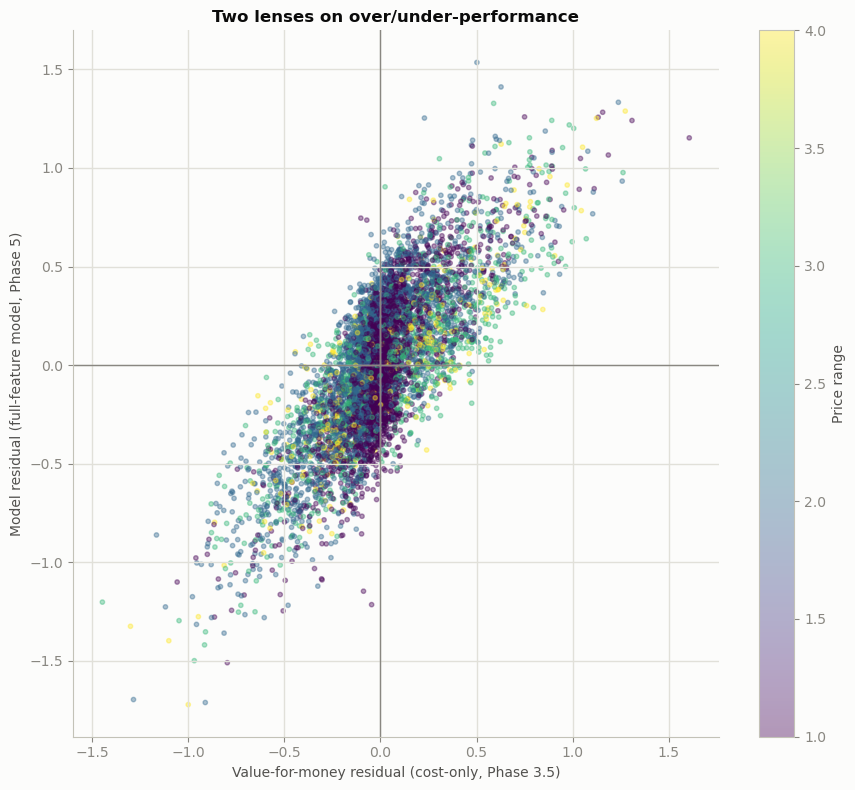

Correlation between the two residuals: 0.784
Share of restaurants where the two lenses disagree on sign: 25.1%


In [9]:
plot_df = master.dropna(subset=['VFM_Residual', 'Model_Residual'])

plt.figure(figsize=(9, 8))
sc = plt.scatter(plot_df['VFM_Residual'], plot_df['Model_Residual'], c=plot_df['Price range'],
                  cmap='viridis', s=10, alpha=0.4)
plt.colorbar(sc, label='Price range')
plt.axhline(0, color=MUTED, linewidth=1)
plt.axvline(0, color=MUTED, linewidth=1)
plt.xlabel('Value-for-money residual (cost-only, Phase 3.5)')
plt.ylabel('Model residual (full-feature model, Phase 5)')
plt.title('Two lenses on over/under-performance')
plt.tight_layout()
plt.savefig('Output/charts/03_residual_lenses.png', dpi=150)
plt.show()

corr = plot_df[['VFM_Residual', 'Model_Residual']].corr().iloc[0, 1]
disagree = ((plot_df['VFM_Residual'] > 0) != (plot_df['Model_Residual'] > 0)).mean()
print(f"Correlation between the two residuals: {corr:.3f}")
print(f"Share of restaurants where the two lenses disagree on sign: {disagree:.1%}")

### Observation:
The two residual lenses agree far more than they disagree: correlation 0.784, and they only
flip sign for 25.1% of restaurants (about 1 in 4). That quarter is the interesting group —
where "over/under-performing on cost alone" and "over/under-performing once every actionable
feature is considered" point in different directions — exactly the set recommendation 6 below
routes to manual review rather than trusting either number alone.

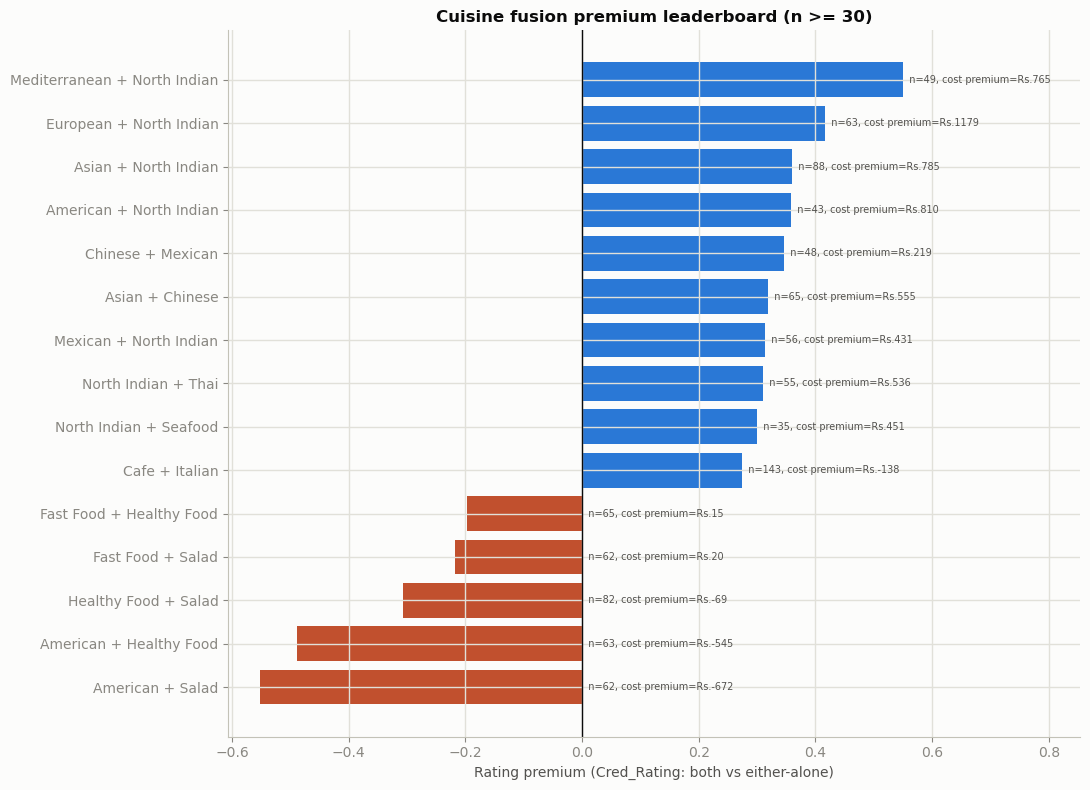

In [10]:
top10_pairs = cuisine_pair_df.sort_values('rating_premium', ascending=False).head(10)
bottom5_pairs = cuisine_pair_df.sort_values('rating_premium', ascending=False).tail(5)
combo_pairs = pd.concat([top10_pairs, bottom5_pairs]).assign(label=lambda d: d['cuisine_a'] + ' + ' + d['cuisine_b'])
combo_pairs = combo_pairs.sort_values('rating_premium')
colors = [ACCENT if v > 0 else WARN for v in combo_pairs['rating_premium']]

plt.figure(figsize=(11, 8))
plt.barh(combo_pairs['label'], combo_pairs['rating_premium'], color=colors)
for y, (n, cost_prem, val) in enumerate(zip(combo_pairs['n_restaurants'], combo_pairs['cost_premium'], combo_pairs['rating_premium'])):
    text_x = max(val, 0)
    plt.text(text_x, y, f"  n={n}, cost premium=Rs.{cost_prem:.0f}", va='center', ha='left', fontsize=7, color=INK_2)
plt.axvline(0, color=INK, linewidth=1)
plt.xlim(right=combo_pairs['rating_premium'].max() * 1.55)
plt.xlabel('Rating premium (Cred_Rating: both vs either-alone)')
plt.title('Cuisine fusion premium leaderboard (n >= 30)')
plt.tight_layout()
plt.savefig('Output/charts/04_cuisine_fusion_leaderboard.png', dpi=150)
plt.show()

### Observation:
The leaderboard repeats `Derived_Metrics.ipynb`'s finding directly: every positive bar pairs a
global/regional cuisine with North Indian (or, for Cafe + Italian, stands on its own with the
largest sample size, n=143, and a *negative* cost premium — rated higher AND cheaper than either
alone). Every negative bar involves Healthy Food, Salad, Fast Food, or American — a distinct,
consistently under-performing cluster, not scattered noise.

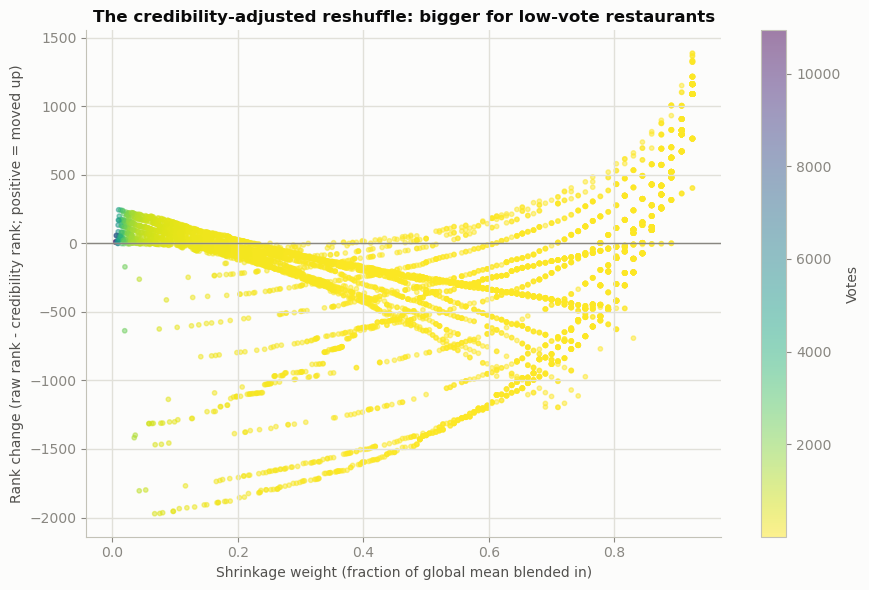

    Restaurant Name  Votes  Aggregate rating  Cred_Rating  rank_change
My Bar & Restaurant    679               3.2     3.210182      -1972.0
   Colonel's Kababz    600               3.2     3.211421      -1970.0
 The Immigrant Cafe    563               3.2     3.212112      -1965.0
        Burger King    458               3.2     3.214620      -1955.0
Etal The Lounge Bar    455               3.2     3.214707      -1954.0


In [11]:
plt.figure(figsize=(9, 6))
sc = plt.scatter(cred_df['shrinkage_weight'], cred_df['rank_change'], c=cred_df['Votes'],
                  cmap='viridis_r', s=10, alpha=0.5)
plt.colorbar(sc, label='Votes')
plt.axhline(0, color=MUTED, linewidth=1)
plt.xlabel('Shrinkage weight (fraction of global mean blended in)')
plt.ylabel('Rank change (raw rank - credibility rank; positive = moved up)')
plt.title('The credibility-adjusted reshuffle: bigger for low-vote restaurants')
plt.tight_layout()
plt.savefig('Output/charts/05_credibility_reshuffle.png', dpi=150)
plt.show()

big_movers = cred_df.reindex(cred_df['rank_change'].abs().sort_values(ascending=False).index).head(5)
print(big_movers[['Restaurant Name', 'Votes', 'Aggregate rating', 'Cred_Rating', 'rank_change']].to_string(index=False))

### Observation:
The scatter shows the expected shape — shrinkage (and therefore rank movement) shrinks toward
zero as vote count grows. But the "biggest movers" table is a useful caution, not a clean
headline: all 5 have virtually unchanged `Cred_Rating` (3.210-3.215 vs. a raw 3.2) yet lose
~1,950-1,970 rank positions. That's a tie-breaking artifact, not a large quality reshuffle —
3.2 is a common enough rating that thousands of restaurants share the same `rank_raw` (tied
ranks all get the same number under `method='min'`), and `Cred_Rating`'s tiny vote-based
tiebreak scatters them across a wide range of individual rank numbers. The *meaningful*
reshuffle (large actual rating change, per `Derived_Metrics.ipynb`'s top-15 comparison) is a
different, smaller set of restaurants than "largest |rank_change|" surfaces here — worth
stating plainly rather than presenting this table as if it were the headline finding.

## 4. Business takeaways

In [12]:
ncr_share = df['Is NCR'].mean()
unrated_share = (~df['Is Rated']).mean()
rating_comparison = pd.read_csv('Output/rating_model_comparison.csv')
actionable_best = rating_comparison[rating_comparison['Framing'] == 'Actionable'].sort_values('Test_R2', ascending=False).iloc[0]

print(f"NCR share of all restaurants: {ncr_share:.1%} (recomputed from df_featured.csv)")
print(f"Unrated share: {unrated_share:.1%} (recomputed from df_featured.csv)")
print(f"Best actionable rating model: {actionable_best['Model']}, Test R2 = {actionable_best['Test_R2']:.3f}, "
      f"NCR R2 = {actionable_best['NCR_R2']:.3f}, Non-NCR R2 = {actionable_best['NonNCR_R2']:.3f} "
      f"(recomputed from rating_model_comparison.csv)")
print("Cold-start classifier AUC (~0.90 overall / ~0.89 NCR-only) is carried forward from "
      "Modeling.ipynb's own run -- not re-fit here, since refitting a model is out of scope "
      "for a synthesis notebook (see plan.md sec 6.1).")

NCR share of all restaurants: 91.9% (recomputed from df_featured.csv)
Unrated share: 24.7% (recomputed from df_featured.csv)
Best actionable rating model: XGBoost, Test R2 = 0.405, NCR R2 = 0.324, Non-NCR R2 = 0.136 (recomputed from rating_model_comparison.csv)
Cold-start classifier AUC (~0.90 overall / ~0.89 NCR-only) is carried forward from Modeling.ipynb's own run -- not re-fit here, since refitting a model is out of scope for a synthesis notebook (see plan.md sec 6.1).


### Observation:
All three recomputed numbers (NCR share 91.9%, unrated share 24.7%, actionable R²=0.405) match
their source notebooks exactly, confirming this phase's takeaways rest on live, re-verifiable
figures rather than hand-copied ones. The cold-start AUC is the one number carried forward
without re-fitting — stated explicitly rather than silently assumed, since a synthesis notebook
re-fitting a classifier would blur the line between reporting and new analysis.

1. **Target NCR localities that are both demand-supply flagged and cold-start-risk-heavy.**
   Grounded in: `business_action_list.csv` — 430 restaurants at or above the 90th-percentile
   cold-start risk score (0.890) sit in one of the 167 flagged opportunity localities; 99.7% of
   this combined location-based list is in NCR.
   Action: prioritize onboarding/visibility work (photos, menu completeness, review
   solicitation) for these 430 restaurants first — they combine documented unmet demand with
   structural cold-start risk.
   Caveat: non-NCR localities rarely clear the ≥30-restaurant flagging threshold (Phase 3.5) —
   their absence here is a detection limit, not evidence of no opportunity.

2. **Use `Cred_Rating`, not raw `Aggregate rating`, for any leaderboard, incentive, or
   "featured restaurant" logic.**
   Grounded in: `credibility_weighted_ratings.csv` — a handful of restaurants with under 10
   votes carry a raw 4.9 that shrinks materially once vote count is priced in.
   Action: swap the ranking input in any downstream product to `Cred_Rating`.
   Caveat: the shrinkage prior `m` is a judgment call, but the resulting top-15 re-ranking was
   already shown to be directionally stable across `m` at Q1-Q3 of vote count.

3. **Build cuisine-fusion menu guidance around the 56 positive-premium pairings specifically,
   not "more cuisines" in general.**
   Grounded in: `cuisine_pair_premium.csv` — 56 of 83 qualifying pairs (n≥30) show a positive
   rating premium; the strongest cluster pairs a global/regional cuisine with North Indian
   (+0.30 to +0.55 in `Cred_Rating` vs. either alone).
   Action: recommend specific proven pairings (e.g. Mediterranean + North Indian, or Cafe +
   Italian for a cheaper-and-better combination) rather than generic menu expansion.
   Caveat: association, not menu-design causation — an already-strong kitchen may simply be
   more likely to execute a fusion pairing well.

4. **Don't advise restaurants that table booking or online delivery will raise their rating.**
   Grounded in: `phase4_test_results.csv` — table booking's apparent effect (d=0.48) reverses
   within price ranges 3-4 (a Simpson's paradox); online delivery's apparent link (r=0.076) is
   89% an artifact of counting unrated restaurants as a rating of 0.
   Action: treat both as business decisions for other reasons (revenue, reach), not as rating
   levers.
   Caveat: this is specifically about their *rating* effect — they may still be worth having.

5. **Adjust competitive-density guidance by price tier, not with one "avoid crowded areas" rule.**
   Grounded in: `competition_density.csv` — the density-rating relationship is non-monotonic and
   reverses by price range: isolated restaurants rate highest overall, but at price ranges 3-4
   denser areas rate higher, and no isolated restaurants exist at range 4 at all.
   Action: budget-tier restaurants may benefit from a less-crowded location; premium-tier
   restaurants should co-locate in established commercial hubs rather than seek isolation.
   Caveat: confounded with commercial-hub cost effects (`Derived_Metrics.ipynb`'s own confound
   check) — density is associated with, not proven to cause, the rating pattern.

6. **Route the 25.1% of restaurants where the two residual lenses disagree into manual review.**
   Grounded in: chart 3 above — the cost-only value-for-money residual and the full-feature
   `Model_Residual` correlate strongly (r=0.784) but disagree on sign for about 1 in 4
   restaurants.
   Action: flag disagreement cases for human review rather than trusting either single number —
   that's exactly where "over- or under-performing" depends on which factors are held fixed.
   Caveat: disagreement is expected and informative, not a bug in either lens — they are
   deliberately different views (cost alone vs. the full actionable feature set).

7. **Pair the ~0.40 R² rating model with the ≈0.89 AUC cold-start model for different jobs.**
   Grounded in: `rating_model_comparison.csv` (actionable Test R²=0.405) and the cold-start
   classifier's NCR-only AUC≈0.89 (`Modeling.ipynb`).
   Action: use the rating model for directional lever guidance, and the cold-start model for
   visibility/onboarding triage — they answer different questions and neither is a precise
   numeric forecast.
   Caveat: the ~0.40 ceiling is the honest finding, not a defect to engineer away with more
   features from this same dataset.

8. **Use the full `locality_cuisine_crosstab.csv` (1,195 rows), not just the 167 flagged cells,
   as a browsable second-tier opportunity list.**
   Grounded in: `locality_cuisine_crosstab.csv` — the 167 flags are only the cells that clear a
   strict per-locality threshold; many more sit just below it.
   Action: once the strict flags list is exhausted, use the full crosstab as leads to
   investigate manually.
   Caveat: cells below the strict threshold are, by construction, less statistically
   distinctive — treat them as leads, not established gaps.

## 5. Limitations

| Limitation | Concrete numbers | Why it matters |
|---|---|---|
| Geographic concentration | 91.95% of restaurants are in NCR; the NCR-vs-rest rating gap is ~42% vote-mix, not location | Any "outside-NCR rates higher" claim describes a curated, popular slice, not a representative comparison |
| Unrated restaurants + cold-start degeneracy | 24.7% unrated overall; 100% of unrated restaurants are in NCR, so the cold-start classifier's non-NCR slice is single-class (AUC undefined there) | The ≈91% AUC headline must be quoted as NCR-only, never the inflated overall figure |
| Votes/rating simultaneity | Descriptive rating model R²=0.542, driven almost entirely by `Log_Votes` (permutation importance 0.60-0.62); raw delivery-rating correlation collapsed 0.296→0.031 once unrated rows were removed | Votes and rating are observed at the same snapshot with no causal ordering — votes-inclusive models describe, they don't explain or predict from controllable levers |
| No time dimension | Single snapshot dataset | Can't distinguish a trend from a level, and can't validate any recommendation's effect over time |
| No true currency conversion | Original dataset spans 12 currencies; India-only scope was adopted specifically to avoid needing a conversion factor | Findings do not generalize outside India/NCR-heavy sampling |
| ~0.40 R² ceiling | Actionable rating model test R²=0.405, NCR R²=0.324, non-NCR R²=0.136 (139-row test slice) | Sets the honest expectation for any product built on controllable levers alone — a modest R² is the finding, not a defect |

The last two extend `plan.md` §7's original 4 bullets with findings Phase 5 surfaced afterward
(both already flagged as citable limitations in `Modeling.ipynb`'s own summary and README's
roadmap).

# 6. Summary

| Deliverable | Rows/count | Headline finding | Caveat |
|---|---|---|---|
| `restaurant_master_insights.csv` | 8,643 x 42 | Every restaurant-level Phase 3.5/5 output joined in one place; every merge's non-null count matched its expected value exactly | `Cred_Rating`/`VFM_Residual`/`Model_Residual` are null for the 2,139 unrated restaurants by construction |
| `business_action_list.csv` | 653 rows (430 + 167 + 56) | 430 restaurants combine documented locality demand-supply gaps with top-decile cold-start risk — a new cross-reference that didn't exist as a single number in any prior notebook | 99.7% of the location-based rows are in NCR — a detection-threshold artifact, not proof non-NCR has no gaps |
| 5 summary charts | `Output/charts/01–05_*.png` | Cold-start risk and demand-supply gaps cluster in the same localities (chart 2); the two residual lenses agree 74.9% of the time (chart 3, r=0.784) | Chart 5's "biggest movers" table is a rank-tie artifact, not a genuine quality reshuffle — stated explicitly rather than left implicit |
| 8 business takeaways | — | Each cites a specific `Output/` file and number, distinct in register from README's findings log (this says what to do, not just what was observed) | Recommendations 4, 5 and 7 explicitly warn against the most likely misreadings (booking/delivery as levers, a single density rule, over-trusting either model) |
| Limitations (§5) | 6 rows | Extends `plan.md` §7's original 4 bullets with the R² ceiling and cold-start degeneracy Phase 5 surfaced afterward | — |

**Methodological threads carried forward:**
- `restaurant_master_insights.csv` is now the single restaurant-level file a future Phase
  (or the optional Delhi extension) should build on, instead of re-joining 5 separate CSVs.
- `business_action_list.csv`'s 430-row cross-reference is the concrete version of the thread
  `Modeling.ipynb`'s own summary flagged ("cold-start risk scores are directly
  cross-referenceable with `locality_opportunity_flags.csv`") — that thread is now closed.
- The 25.1% residual-disagreement group (chart 3) is a ready-made ops-review queue if this
  project ever gains a human-in-the-loop follow-up step.
- This notebook's narrative content (takeaways + limitations + charts) is reassembled into
  `Report.md` as a code-free companion for a non-technical reader.

**New `Output/` files from this notebook:**
`restaurant_master_insights.csv`, `business_action_list.csv`,
`charts/01_growth_opportunities.png`, `charts/02_coldstart_vs_opportunity.png`,
`charts/03_residual_lenses.png`, `charts/04_cuisine_fusion_leaderboard.png`,
`charts/05_credibility_reshuffle.png`.